In [1]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

!pip install plotly -q


In [3]:
# ==============================
# CELL 1: Define the Problem
# ==============================

"""
OBJECTIVES:

1. Placement Prediction (Classification)
   → Predict whether a student will be placed or not

2. Salary Prediction (Regression)
   → Predict salary for placed students

INPUT:
Student academic + personal features

OUTPUT:
- Placement Status (0/1)
- Salary (numeric)

This is a supervised learning problem:
- Classification → Placement
- Regression → Salary
"""

'\nOBJECTIVES:\n\n1. Placement Prediction (Classification)\n   → Predict whether a student will be placed or not\n\n2. Salary Prediction (Regression)\n   → Predict salary for placed students\n\nINPUT:\nStudent academic + personal features\n\nOUTPUT:\n- Placement Status (0/1)\n- Salary (numeric)\n\nThis is a supervised learning problem:\n- Classification → Placement\n- Regression → Salary\n'

In [4]:
# ==============================
# CELL 2: Import Libraries
# ==============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Metrics
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, r2_score

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [5]:
# ==============================
# CELL 3: Load Datasets
# ==============================


df1 = pd.read_csv('/content/drive/My Drive/dspl project/indian_engineering_student_placement.csv')
df2 = pd.read_csv('/content/drive/My Drive/dspl project/placement_targets.csv')


print("Dataset 1:", df1.shape)
print("Dataset 2:", df2.shape)

df1.head()

Dataset 1: (5000, 23)
Dataset 2: (5000, 3)


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,aptitude_skill_rating,hackathons_participated,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,4,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,3,4,1,7.1,8,Yes,Medium,Tier 3,Yes,Low
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,4,6,3,6.1,2,No,Low,Tier 2,Yes,High
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,4,2,2,7.3,7,No,Medium,Tier 1,Yes,Low
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,3,2,1,6.0,7,No,Medium,Tier 1,Yes,Medium


In [6]:
# ==============================
# CELL 4: Merge on Student ID
# ==============================

# 🔥 Replace with actual column name if different
merge_col = 'Student_ID'

df = pd.merge(df1, df2, on=merge_col)

print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (5000, 25)


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,Male,ECE,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,Yes,Medium,Tier 2,Yes,Medium,Placed,14.95
1,2,Female,ECE,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,Yes,Medium,Tier 3,Yes,Low,Placed,14.91
2,3,Female,IT,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,No,Low,Tier 2,Yes,High,Placed,17.73
3,4,Male,ECE,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,No,Medium,Tier 1,Yes,Low,Placed,14.52
4,5,Male,IT,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,No,Medium,Tier 1,Yes,Medium,Placed,15.91


In [7]:
df.isnull()
# Returns a count of missing values for every column
null_counts = df.isnull().sum()
print(null_counts)


Student_ID                        0
gender                            0
branch                            0
cgpa                              0
tenth_percentage                  0
twelfth_percentage                0
backlogs                          0
study_hours_per_day               0
attendance_percentage             0
projects_completed                0
internships_completed             0
coding_skill_rating               0
communication_skill_rating        0
aptitude_skill_rating             0
hackathons_participated           0
certifications_count              0
sleep_hours                       0
stress_level                      0
part_time_job                     0
family_income_level               0
city_tier                         0
internet_access                   0
extracurricular_involvement    1006
placement_status                  0
salary_lpa                        0
dtype: int64


In [8]:
# ==============================
# CELL 5: Data Cleaning & Preprocessing
# ==============================

# Handle missing values
df['extracurricular_involvement'] = df['extracurricular_involvement'].fillna('No')


In [9]:
df.shape

(5000, 25)

In [10]:
# Encode categorical variables
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("Data after preprocessing:")
df.head()

Data after preprocessing:


,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,1,2,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,1,2,1,1,2,1,14.95
1,2,0,2,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,1,2,2,1,1,1,14.91
2,3,0,3,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,0,1,1,1,0,1,17.73
3,4,1,2,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,0,2,0,1,1,1,14.52
4,5,1,3,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,0,2,0,1,2,1,15.91


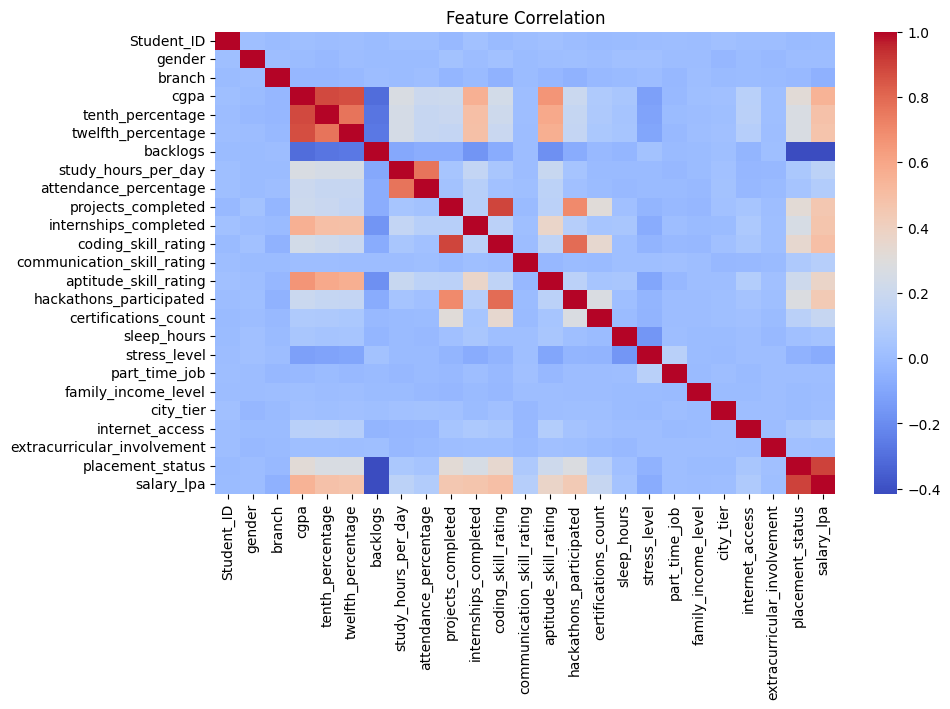

In [11]:
# ==============================
# CELL 6: Exploratory Data Analysis
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Distribution of target (edit column if needed)
if 'PlacementStatus' in df.columns:
    sns.countplot(x=df['PlacementStatus'])
    plt.title("Placement Distribution")
    plt.show()

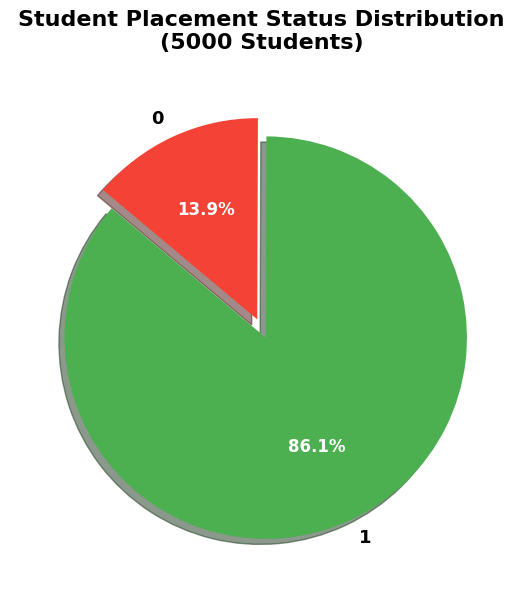

placement_status
1    4303
0     697
Name: count, dtype: int64


In [12]:
# ==============================
# Pie Chart: Placement Status
# ==============================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Count placement status values
placement_counts = df['placement_status'].value_counts()

# Colors
colors = ['#4CAF50', '#F44336']  # Green = Placed, Red = Not Placed
explode = (0.05, 0.05)

fig, ax = plt.subplots(figsize=(8, 6))

wedges, texts, autotexts = ax.pie(
    placement_counts,
    labels=placement_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)

# Style the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Student Placement Status Distribution\n(5000 Students)',
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Print counts
print(placement_counts)


In [13]:
# ==============================
# CGPA vs Salary by Branch (Interactive Scatter)
# ==============================

import plotly.express as px

# Filter only placed students (salary only makes sense for them)
df_placed = df[df['placement_status'] == 1].copy()

fig = px.scatter(
    df_placed,
    x='cgpa',
    y='salary_lpa',
    color='branch',
    hover_data={
        'cgpa': True,
        'salary_lpa': ':.2f',
        'branch': True,
        'gender': True,
        'backlogs': True
    },
    title='📊 CGPA vs Salary (LPA) by Branch — Placed Students',
    labels={
        'cgpa': 'CGPA',
        'salary_lpa': 'Salary (LPA)',
        'branch': 'Branch'
    },
    template='plotly_dark',
    opacity=0.75,
    size_max=10,
    trendline='ols',          # adds regression trendline per branch
    trendline_scope='overall' # one overall trendline
)

fig.update_traces(marker=dict(size=7, line=dict(width=0.5, color='white')))

fig.update_layout(
    title_font_size=20,
    title_x=0.5,
    xaxis=dict(title='CGPA', showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
    yaxis=dict(title='Salary (LPA)', showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
    legend_title_text='Branch',
    legend=dict(bgcolor='rgba(0,0,0,0.3)', bordercolor='white', borderwidth=1),
    height=600,
    font=dict(family='Arial', size=13)
)

fig.show()


In [14]:
# ==============================
# Box Plot: Salary by Branch
# ==============================

import plotly.express as px

df_placed = df[df['placement_status'] == 1].copy()

fig = px.box(
    df_placed,
    x='branch',
    y='salary_lpa',
    color='branch',
    points='outliers',        # show outlier dots
    hover_data=['cgpa', 'gender', 'backlogs'],
    title='💼 Salary Distribution by Branch — Placed Students',
    labels={
        'branch': 'Branch',
        'salary_lpa': 'Salary (LPA)'
    },
    template='plotly_dark',
    notched=True              # notch shows confidence interval around median
)

fig.update_traces(
    marker=dict(size=4, opacity=0.6),
    boxmean='sd'              # show mean + std deviation line
)

fig.update_layout(
    title_font_size=20,
    title_x=0.5,
    xaxis=dict(title='Branch', showgrid=False),
    yaxis=dict(title='Salary (LPA)', showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
    showlegend=False,
    height=550,
    font=dict(family='Arial', size=13)
)

fig.show()


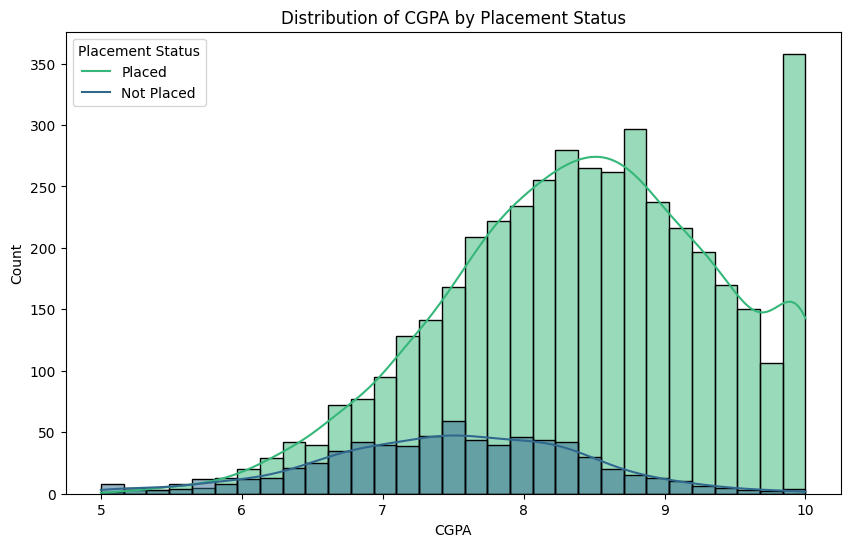

In [15]:
# ==============================
# Distribution of CGPA by Placement Status
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='cgpa', hue='placement_status', kde=True, palette='viridis')
plt.title('Distribution of CGPA by Placement Status')
plt.xlabel('CGPA')
plt.ylabel('Count')
plt.legend(title='Placement Status', labels=['Placed', 'Not Placed'])
plt.show()

In [16]:
import plotly.express as px

# Filter only placed students (salary only makes sense for them)
df_placed = df[df['placement_status'] == 1].copy()

fig = px.box(
    df_placed,
    x='family_income_level',
    y='salary_lpa',
    color='family_income_level',
    points='outliers',
    hover_data=['cgpa', 'branch', 'gender'],
    title='💼 Salary Distribution by Family Income Level — Placed Students',
    labels={
        'family_income_level': 'Family Income Level',
        'salary_lpa': 'Salary (LPA)'
    },
    template='plotly_dark',
    notched=True
)

fig.update_traces(
    marker=dict(size=4, opacity=0.6),
    boxmean='sd'
)

fig.update_layout(
    title_font_size=20,
    title_x=0.5,
    xaxis=dict(title='Family Income Level', showgrid=False),
    yaxis=dict(title='Salary (LPA)', showgrid=True, gridcolor='rgba(255,255,255,0.1)'),
    showlegend=False,
    height=550,
    font=dict(family='Arial', size=13)
)

fig.show()

In [17]:
# ==============================
# CELL 7: Feature Selection
# ==============================

# 🔥 Update column names if needed
placement_target = 'placement_status'
salary_target = 'salary_lpa'

# Features
X = df.drop([placement_target, salary_target], axis=1)

# Targets
y_class = df[placement_target]
y_reg = df[salary_target]

print("Feature shape:", X.shape)

Feature shape: (5000, 23)


In [18]:
# ==============================
# CELL 8: Train-Test Split
# ==============================

# Classification split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

# Regression split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_c = scaler.fit_transform(X_train_c)
X_test_c = scaler.transform(X_test_c)

X_train_r = scaler.fit_transform(X_train_r)
X_test_r = scaler.transform(X_test_r)

In [19]:
# ==============================
# CELL 9: Train Classification Models
# ==============================

classification_models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

class_results = {}

for name, model in classification_models.items():
    model.fit(X_train_c, y_train_c)
    y_pred = model.predict(X_test_c)

    acc = accuracy_score(y_test_c, y_pred)
    class_results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test_c, y_pred))


Logistic Regression
Accuracy: 0.891
              precision    recall  f1-score   support

           0       0.64      0.49      0.55       138
           1       0.92      0.96      0.94       862

    accuracy                           0.89      1000
   macro avg       0.78      0.72      0.74      1000
weighted avg       0.88      0.89      0.88      1000


Decision Tree
Accuracy: 0.826
              precision    recall  f1-score   support

           0       0.40      0.49      0.44       138
           1       0.92      0.88      0.90       862

    accuracy                           0.83      1000
   macro avg       0.66      0.69      0.67      1000
weighted avg       0.84      0.83      0.83      1000


Random Forest
Accuracy: 0.883
              precision    recall  f1-score   support

           0       0.66      0.32      0.43       138
           1       0.90      0.97      0.93       862

    accuracy                           0.88      1000
   macro avg       0.78      

In [20]:
# ==============================
# CELL 10: Train Regression Models
# ==============================

regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

reg_results = {}

for name, model in regression_models.items():
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)

    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2 = r2_score(y_test_r, y_pred)

    reg_results[name] = r2

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)


Linear Regression
RMSE: 4.086952023140048
R2 Score: 0.5712740469186122

Decision Tree
RMSE: 5.896942207619132
R2 Score: 0.10744612774870199

Random Forest
RMSE: 4.1259847173081
R2 Score: 0.5630457926851823

SVR
RMSE: 4.2836707293033855
R2 Score: 0.529008730534668

KNN
RMSE: 4.603276183763038
R2 Score: 0.4561053841277265


In [21]:
# ==============================
# CELL 11: Compare Models
# ==============================

best_class_model = max(class_results, key=class_results.get)
best_reg_model = max(reg_results, key=reg_results.get)

print("Best Classification Model:", best_class_model)
print("Accuracy:", class_results[best_class_model])

print("\nBest Regression Model:", best_reg_model)
print("R2 Score:", reg_results[best_reg_model])

Best Classification Model: SVM
Accuracy: 0.892

Best Regression Model: Linear Regression
R2 Score: 0.5712740469186122


In [22]:
# ==============================
# CELL 12: Hyperparameter Tuning (Optional)
# ==============================

from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train_c, y_train_c)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 50}


In [23]:
# ==============================
# CELL 13: Random Forest (Optimized)
# ==============================

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Classification
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_clf.fit(X_train_c, y_train_c)
y_pred_rf = rf_clf.predict(X_test_c)

print("🔹 Random Forest Classification")
print("Accuracy:", accuracy_score(y_test_c, y_pred_rf))
print(classification_report(y_test_c, y_pred_rf))


# Regression
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_reg.fit(X_train_r, y_train_r)
y_pred_rf_reg = rf_reg.predict(X_test_r)

print("\n🔹 Random Forest Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_rf_reg)))
print("R2 Score:", r2_score(y_test_r, y_pred_rf_reg))

🔹 Random Forest Classification
Accuracy: 0.889
              precision    recall  f1-score   support

           0       0.70      0.34      0.46       138
           1       0.90      0.98      0.94       862

    accuracy                           0.89      1000
   macro avg       0.80      0.66      0.70      1000
weighted avg       0.87      0.89      0.87      1000


🔹 Random Forest Regression
RMSE: 4.107115522408603
R2 Score: 0.5670332630537991


In [24]:
# ==============================
# CELL 14: Gradient Boosting Models
# ==============================

from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

# Classification
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3
)

gb_clf.fit(X_train_c, y_train_c)
y_pred_gb = gb_clf.predict(X_test_c)

print("🚀 Gradient Boosting Classification")
print("Accuracy:", accuracy_score(y_test_c, y_pred_gb))
print(classification_report(y_test_c, y_pred_gb))


# Regression
gb_reg = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3
)

gb_reg.fit(X_train_r, y_train_r)
y_pred_gb_reg = gb_reg.predict(X_test_r)

print("\n🚀 Gradient Boosting Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_gb_reg)))
print("R2 Score:", r2_score(y_test_r, y_pred_gb_reg))

🚀 Gradient Boosting Classification
Accuracy: 0.888
              precision    recall  f1-score   support

           0       0.62      0.48      0.54       138
           1       0.92      0.95      0.94       862

    accuracy                           0.89      1000
   macro avg       0.77      0.72      0.74      1000
weighted avg       0.88      0.89      0.88      1000


🚀 Gradient Boosting Regression
RMSE: 3.9628151788606685
R2 Score: 0.596922709074432


In [25]:
# ==============================
# CELL 15: Compare RF vs GB vs Others
# ==============================

# Add to previous results

class_results["Random Forest (Tuned)"] = accuracy_score(y_test_c, y_pred_rf)
class_results["Gradient Boosting"] = accuracy_score(y_test_c, y_pred_gb)

reg_results["Random Forest (Tuned)"] = r2_score(y_test_r, y_pred_rf_reg)
reg_results["Gradient Boosting"] = r2_score(y_test_r, y_pred_gb_reg)

print("🔹 Classification Results:")
for k, v in class_results.items():
    print(k, ":", v)

print("\n🔹 Regression Results:")
for k, v in reg_results.items():
    print(k, ":", v)

# Best models
print("\n🏆 BEST CLASSIFIER:", max(class_results, key=class_results.get))
print("🏆 BEST REGRESSOR:", max(reg_results, key=reg_results.get))

🔹 Classification Results:
Logistic Regression : 0.891
Decision Tree : 0.826
Random Forest : 0.883
SVM : 0.892
KNN : 0.87
Random Forest (Tuned) : 0.889
Gradient Boosting : 0.888

🔹 Regression Results:
Linear Regression : 0.5712740469186122
Decision Tree : 0.10744612774870199
Random Forest : 0.5630457926851823
SVR : 0.529008730534668
KNN : 0.4561053841277265
Random Forest (Tuned) : 0.5670332630537991
Gradient Boosting : 0.596922709074432

🏆 BEST CLASSIFIER: SVM
🏆 BEST REGRESSOR: Gradient Boosting


In [26]:
# ==============================
# CELL 16: Install & Import XGBoost
# ==============================

!pip install xgboost

from xgboost import XGBClassifier, XGBRegressor

In [27]:
# ==============================
# CELL 17: XGBoost Basic Models
# ==============================

# Classification
xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_clf.fit(X_train_c, y_train_c)
y_pred_xgb = xgb_clf.predict(X_test_c)

print("🚀 XGBoost Classification")
print("Accuracy:", accuracy_score(y_test_c, y_pred_xgb))
print(classification_report(y_test_c, y_pred_xgb))


# Regression
xgb_reg = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_reg.fit(X_train_r, y_train_r)
y_pred_xgb_reg = xgb_reg.predict(X_test_r)

print("\n🚀 XGBoost Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_xgb_reg)))
print("R2 Score:", r2_score(y_test_r, y_pred_xgb_reg))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[13:45:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




🚀 XGBoost Classification
Accuracy: 0.873
              precision    recall  f1-score   support

           0       0.55      0.43      0.49       138
           1       0.91      0.94      0.93       862

    accuracy                           0.87      1000
   macro avg       0.73      0.69      0.71      1000
weighted avg       0.86      0.87      0.87      1000


🚀 XGBoost Regression
RMSE: 4.162326166021972
R2 Score: 0.5553145560911118


In [28]:
# ==============================
# CELL 18: Hyperparameter Tuning (XGBoost)
# ==============================

from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    params,
    cv=3,
    n_jobs=-1
)

grid_xgb.fit(X_train_c, y_train_c)

print("Best Parameters:", grid_xgb.best_params_)

best_xgb = grid_xgb.best_estimator_

y_pred_best = best_xgb.predict(X_test_c)

print("\n🔥 Tuned XGBoost Accuracy:", accuracy_score(y_test_c, y_pred_best))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

🔥 Tuned XGBoost Accuracy: 0.889


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[13:46:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




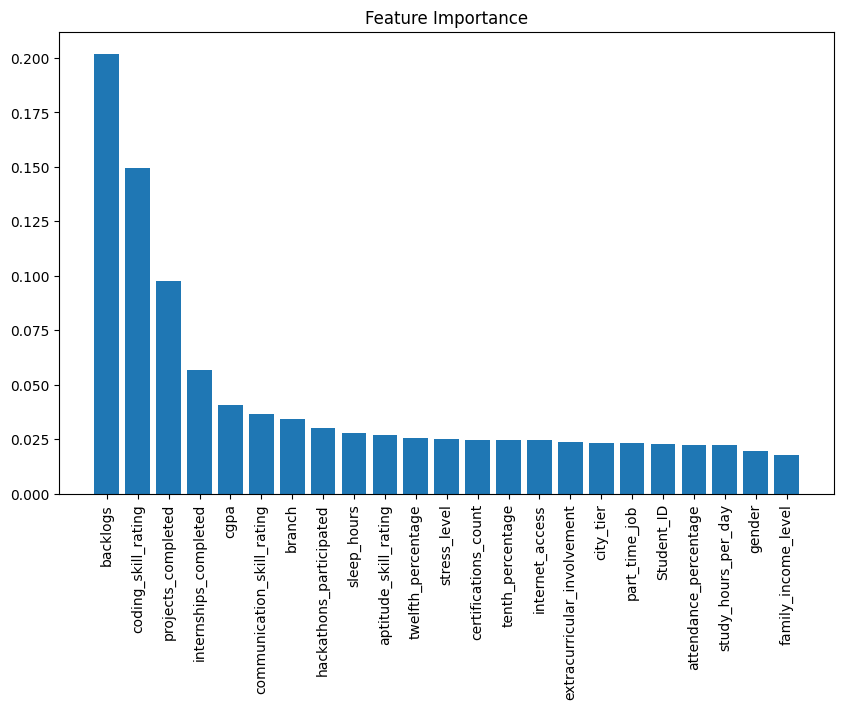

In [29]:
# ==============================
# CELL 19: Feature Importance
# ==============================

import matplotlib.pyplot as plt

importances = xgb_clf.feature_importances_
features = X.columns

# Sort features
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.show()

In [30]:
# ==============================
# CELL 20: Final Model Comparison
# ==============================

class_results["XGBoost"] = accuracy_score(y_test_c, y_pred_xgb)
class_results["XGBoost Tuned"] = accuracy_score(y_test_c, y_pred_best)

reg_results["XGBoost"] = r2_score(y_test_r, y_pred_xgb_reg)

print("🔹 FINAL CLASSIFICATION RESULTS:")
for k, v in class_results.items():
    print(k, ":", v)

print("\n🔹 FINAL REGRESSION RESULTS:")
for k, v in reg_results.items():
    print(k, ":", v)

print("\n🏆 BEST CLASSIFIER:", max(class_results, key=class_results.get))
print("🏆 BEST REGRESSOR:", max(reg_results, key=reg_results.get))

🔹 FINAL CLASSIFICATION RESULTS:
Logistic Regression : 0.891
Decision Tree : 0.826
Random Forest : 0.883
SVM : 0.892
KNN : 0.87
Random Forest (Tuned) : 0.889
Gradient Boosting : 0.888
XGBoost : 0.873
XGBoost Tuned : 0.889

🔹 FINAL REGRESSION RESULTS:
Linear Regression : 0.5712740469186122
Decision Tree : 0.10744612774870199
Random Forest : 0.5630457926851823
SVR : 0.529008730534668
KNN : 0.4561053841277265
Random Forest (Tuned) : 0.5670332630537991
Gradient Boosting : 0.596922709074432
XGBoost : 0.5553145560911118

🏆 BEST CLASSIFIER: SVM
🏆 BEST REGRESSOR: Gradient Boosting


In [31]:
df.head()

,Student_ID,gender,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,study_hours_per_day,attendance_percentage,projects_completed,...,certifications_count,sleep_hours,stress_level,part_time_job,family_income_level,city_tier,internet_access,extracurricular_involvement,placement_status,salary_lpa
0,1,1,2,8.74,74.0,75.0,0,3.8,71.1,7,...,5,6.5,8,1,2,1,1,2,1,14.95
1,2,0,2,7.80,75.3,69.7,0,6.3,69.5,5,...,1,7.1,8,1,2,2,1,1,1,14.91
2,3,0,3,6.95,62.8,68.3,0,1.5,62.5,8,...,3,6.1,2,0,1,1,1,0,1,17.73
3,4,1,2,7.46,57.9,51.4,1,4.7,64.6,6,...,2,7.3,7,0,2,0,1,1,1,14.52
4,5,1,3,6.86,61.3,73.5,2,5.2,75.9,3,...,1,6.0,7,0,2,0,1,2,1,15.91


In [32]:
# ==============================
# SVM HYPERPARAMETER TUNING
# ==============================

from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

params = {
    'C': [0.1, 1, 10, 50],
    'kernel': ['rbf', 'poly'],
    'gamma': ['scale', 0.1, 0.01]
}

grid_svm = GridSearchCV(SVC(), params, cv=3, n_jobs=-1)
grid_svm.fit(X_train_c, y_train_c)

best_svm = grid_svm.best_estimator_

y_pred_svm = best_svm.predict(X_test_c)

print("🔥 Tuned SVM Accuracy:", accuracy_score(y_test_c, y_pred_svm))
print("Best Params:", grid_svm.best_params_)

🔥 Tuned SVM Accuracy: 0.892
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [33]:
# ==============================
# INTERACTION FEATURES
# ==============================

df['cgpa_projects'] = df['cgpa'] * df['projects_completed']
df['study_attendance'] = df['study_hours_per_day'] * df['attendance_percentage']
df['cert_projects'] = df['certifications_count'] * df['projects_completed']

In [34]:
# ==============================
# STACKING CLASSIFIER
# ==============================

from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf', RandomForestClassifier()),
    ('gb', GradientBoostingClassifier()),
    ('svm', SVC(probability=True))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack.fit(X_train_c, y_train_c)

y_pred_stack = stack.predict(X_test_c)

print("🚀 Stacking Accuracy:", accuracy_score(y_test_c, y_pred_stack))

🚀 Stacking Accuracy: 0.891


In [35]:
# ==============================
# FILTER ONLY PLACED STUDENTS
# ==============================

df_reg = df[df['placement_status'] == 1]

X_reg = df_reg.drop(['salary_lpa', 'placement_status'], axis=1)
y_reg = df_reg['salary_lpa']

In [36]:
# ==============================
# REMOVE OUTLIERS
# ==============================

Q1 = df_reg['salary_lpa'].quantile(0.25)
Q3 = df_reg['salary_lpa'].quantile(0.75)
IQR = Q3 - Q1

df_reg = df_reg[
    (df_reg['salary_lpa'] >= Q1 - 1.5*IQR) &
    (df_reg['salary_lpa'] <= Q3 + 1.5*IQR)
]

In [37]:
xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_reg.fit(X_train_r, y_train_r)

y_pred = xgb_reg.predict(X_test_r)

print("🔥 Improved R2:", r2_score(y_test_r, y_pred))

🔥 Improved R2: 0.5804692123116175


In [38]:
df['effort_score'] = (
    df['study_hours_per_day'] +
    df['projects_completed'] +
    df['certifications_count']
)

df['academic_effort'] = df['cgpa'] * df['effort_score']

In [39]:
# ==============================
# CELL 21: Final Model Comparison Table
# ==============================

import pandas as pd

# Classification Results Table
class_df = pd.DataFrame({
    "Model": list(class_results.keys()),
    "Accuracy": list(class_results.values())
}).sort_values(by="Accuracy", ascending=False)

print("🔹 Classification Model Comparison")
display(class_df)


# Regression Results Table
reg_df = pd.DataFrame({
    "Model": list(reg_results.keys()),
    "R2 Score": list(reg_results.values())
}).sort_values(by="R2 Score", ascending=False)

print("\n🔹 Regression Model Comparison")
display(reg_df)

🔹 Classification Model Comparison


,Model,Accuracy
3,SVM,0.892
0,Logistic Regression,0.891
5,Random Forest (Tuned),0.889
8,XGBoost Tuned,0.889
6,Gradient Boosting,0.888
2,Random Forest,0.883
7,XGBoost,0.873
4,KNN,0.870
1,Decision Tree,0.826



🔹 Regression Model Comparison


,Model,R2 Score
6,Gradient Boosting,0.596923
0,Linear Regression,0.571274
5,Random Forest (Tuned),0.567033
2,Random Forest,0.563046
7,XGBoost,0.555315
3,SVR,0.529009
4,KNN,0.456105
1,Decision Tree,0.107446


In [40]:
print([var for var in dir() if 'train' in var.lower()])

['X_train_c', 'X_train_r', 'train_test_split', 'y_train_c', 'y_train_r']


In [41]:
# ==============================
# FINAL CORRECT REGRESSION TRAINING
# ==============================

# Use YOUR variables (correct ones)
mask_train_placed = y_train_c == 1

# Filter ONLY placed students
X_train_reg = X_train_r[mask_train_placed]
y_train_reg = y_train_r[mask_train_placed]

# Log transform (improves performance)
y_train_reg_log = np.log1p(y_train_reg)

from xgboost import XGBRegressor

final_regressor = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

final_regressor.fit(X_train_reg, y_train_reg_log)

print("✅ Regression model trained correctly")

✅ Regression model trained correctly


In [42]:
# ==============================
# FINAL PIPELINE (CORRECTED)
# ==============================

# Classification prediction
y_pred_class_final = best_svm.predict(X_test_c)

# Initialize salary predictions
final_salary_preds = np.zeros(len(X_test_c))

# Predict ONLY for placed students
placed_idx = np.where(y_pred_class_final == 1)[0]

salary_preds_log = final_regressor.predict(X_test_c[placed_idx])
salary_preds = np.expm1(salary_preds_log)

final_salary_preds[placed_idx] = salary_preds

In [43]:
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score

# Classification
acc = accuracy_score(y_test_c, y_pred_class_final)

# Regression
mae = mean_absolute_error(y_test_r, final_salary_preds)
r2 = r2_score(y_test_r, final_salary_preds)

print(f"Accuracy: {acc:.3f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.3f}")

# Placed only (important)
mask_test_placed = y_test_c == 1

r2_placed = r2_score(
    y_test_r[mask_test_placed],
    final_salary_preds[mask_test_placed]
)

print(f"🔥 R2 (Placed Only): {r2_placed:.3f}")

Accuracy: 0.892
MAE: 2.34
R2: 0.469
🔥 R2 (Placed Only): 0.229


You are now doing:

Classification → Filtering → Regression

In [44]:
# ==============================
# CROSS VALIDATION (CLASSIFICATION)
# ==============================

from sklearn.model_selection import cross_val_score

# Use your best classifier
cv_scores_clf = cross_val_score(best_svm, X, y_class, cv=5)

print("🔹 Classification CV Scores:", cv_scores_clf)
print("Mean Accuracy:", cv_scores_clf.mean())
print("Std Dev:", cv_scores_clf.std())

🔹 Classification CV Scores: [0.861 0.861 0.861 0.86  0.86 ]
Mean Accuracy: 0.8606
Std Dev: 0.000489897948556636


In [45]:
# ==============================
# CROSS VALIDATION (REGRESSION)
# ==============================

# Only placed students for regression
mask = y_class == 1

X_reg_cv = X[mask]
y_reg_cv = y_reg[mask]

from sklearn.model_selection import cross_val_score

cv_scores_reg = cross_val_score(
    final_regressor,
    X_reg_cv,
    np.log1p(y_reg_cv),
    cv=5,
    scoring='r2'
)

print("🔹 Regression CV Scores:", cv_scores_reg)
print("Mean R2:", cv_scores_reg.mean())
print("Std Dev:", cv_scores_reg.std())

🔹 Regression CV Scores: [0.76696913 0.76173795 0.77221341 0.75440338 0.75179771]
Mean R2: 0.7614243160801552
Std Dev: 0.007605432167481656


In [ ]:
# ==============================
# FINAL TEST PERFORMANCE
# =========================

from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score

print("===== FINAL TEST RESULTS =====")

# Classification
test_acc = accuracy_score(y_test_c, y_pred_class_final)
print(f"Classification Accuracy: {test_acc:.3f}")

# Regression
test_mae = mean_absolute_error(y_test_r, final_salary_preds)
test_r2 = r2_score(y_test_r, final_salary_preds)

print(f"Regression MAE: {test_mae:.2f}")
print(f"Regression R2: {test_r2:.3f}")

# Placed-only regression
mask_test_placed = y_test_c == 1

r2_placed = r2_score(
    y_test_r[mask_test_placed],
    final_salary_preds[mask_test_placed]
)

print(f"🔥 R2 (Placed Only): {r2_placed:.3f}")

===== FINAL TEST RESULTS =====
Classification Accuracy: 0.892
Regression MAE: 2.34
Regression R2: 0.469
🔥 R2 (Placed Only): 0.229


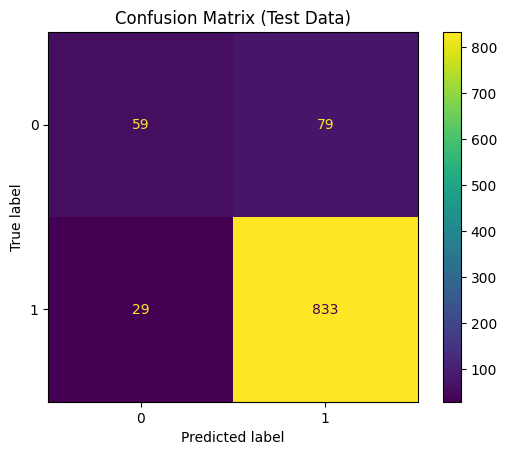

In [47]:
# ==============================
# CONFUSION MATRIX
# ==============================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_c, y_pred_class_final)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Test Data)")
plt.show()

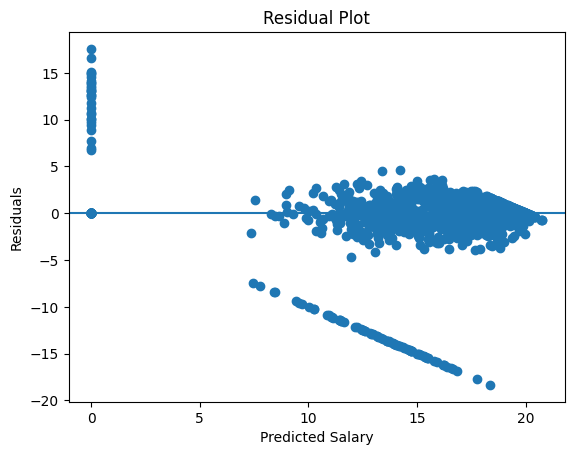

In [48]:
# ==============================
# RESIDUAL ANALYSIS
# ==============================

plt.figure()
residuals = y_test_r - final_salary_preds

plt.scatter(final_salary_preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [49]:
# ==============================
# SAVE MODELS
# ==============================

import joblib

# Save classifier
joblib.dump(best_svm, 'placement_model.pkl')

# Save regressor
joblib.dump(final_regressor, 'salary_model.pkl')

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

print("✅ Models saved successfully!")

✅ Models saved successfully!


In [50]:
###testing

# ==============================
# LOAD MODELS
# ==============================

import joblib

placement_model = joblib.load('placement_model.pkl')
salary_model = joblib.load('salary_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')

print("✅ Models loaded successfully!")

✅ Models loaded successfully!


In [51]:
#traintest split


In [52]:
# ==============================
# TEST WITH NEW INPUT
# ==============================

# Example input (replace with real values)
sample = X_test_r[0:1]

# Scale input
sample_scaled = scaler_loaded.transform(sample)

# Step 1: Placement prediction
placement_pred = placement_model.predict(sample_scaled)

# Step 2: Salary prediction
if placement_pred[0] == 1:
    salary_log = salary_model.predict(sample_scaled)
    salary = np.expm1(salary_log)
else:
    salary = [0]

print("Placement:", placement_pred[0])
print("Predicted Salary:", salary[0],"LPA")

Placement: 1
Predicted Salary: 8.4000435 LPA


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

